# V5 Feasibility: Hierarchical Stress Decomposition (Iteration 4)

## TL;DR

This diagnostic tests a specific explanation for the V4 symbolic-regression
failure. A single pointwise formula may be trying to learn two different
tasks at once:

1. the overall stress level and upper-tail amplitude of an FEM case; and
2. the normalised spatial stress shape inside that case.

The notebook therefore compares a direct nonlinear control with two
hierarchical reconstructions:

\[
\hat\sigma_{e,c}=\hat B_c+\hat A_c\hat S_{e,c},
\]

where \(B_c\) is case mean stress, \(A_c=\sigma_{95,c}-B_c\), and
\(S_{e,c}\) is the normalised element-level shape.

The **oracle hierarchy** uses the true validation-case \(A_c,B_c\) only
to test shape learnability. It is not deployable. The **deployable
hierarchy** predicts \(A_c,B_c\) exclusively from summaries of available
input fields. The locked 50-case final test is never read.


### Execution note

Run this notebook independently and wait for it to finish before starting another iteration. The models evaluate complete FEM cases and parallel notebook runs would compete for memory. The final-test cases remain sealed.


## Context & Methods

### Key assumptions

- One complete FEM case remains the independent experimental unit.
- The frozen iteration-4 split is used: 119 training, 15 validation
  and 15 internal-test cases. This preserves the pre-registered case-level
  split and similarity-group constraints used throughout CT3.
- All validation and internal-test elements are evaluated. Training uses
  the same deterministic 5,000-row-per-case tail-stratified design already
  audited in V4, so this experiment is directly comparable and quick.
- Exported post-deformation coordinates are treated as available inputs.
- Mean and P95 stress are decomposition targets during training, not model
  inputs. At deployment they are predicted from input-field summaries.
- This is a feasibility diagnostic using nonlinear controls. It does not
  produce or approve the final symbolic formula.

### Fair comparison

The direct and shape models use the same model family, sampled rows,
weights and predictor matrix. The only intentional difference is whether
the target is raw stress or within-case normalised stress. This isolates
the value of the decomposition itself.


## 1. Setup


In [1]:
from pathlib import Path
import sys
import pandas as pd

CWD = Path.cwd().resolve()
if (CWD / "src" / "ct3_common.py").exists():
    PACKAGE_ROOT = CWD
elif CWD.name == "notebooks" and (CWD.parent / "src" / "ct3_common.py").exists():
    PACKAGE_ROOT = CWD.parent
elif (CWD / "NotebookCT3" / "src" / "ct3_common.py").exists():
    PACKAGE_ROOT = CWD / "NotebookCT3"
else:
    raise FileNotFoundError("Could not locate NotebookCT3 from the current directory")

sys.path.insert(0, str(PACKAGE_ROOT / "src"))
from hierarchical_feasibility import FeasibilityConfig, run_feasibility

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)

CONFIG = FeasibilityConfig(
    iteration=4,
    rows_per_case=5_000,
    hgb_max_iter=180,
    output_subdir="iteration_4_pilot",
    force_rebuild_sample=False,
)
print("Package root:", PACKAGE_ROOT)
print("Configuration:", CONFIG)


Package root: /Users/novwin/Documents/University/University of Manchester/毕设项目/Nuclear graphite/NotebookCT3
Configuration: FeasibilityConfig(iteration=4, rows_per_case=5000, hgb_max_iter=180, output_subdir='iteration_4_pilot', force_rebuild_sample=False)


## 2. Run the Diagnostic

The run has four bounded stages: reuse/assemble the audited training
sample, select a case-level amplitude model using validation cases, fit
direct and normalised-shape controls, then evaluate every element in the
validation and internal-test cases.


In [2]:
RESULTS = run_feasibility(PACKAGE_ROOT, CONFIG)


Hierarchical feasibility diagnostic
Package root: /Users/novwin/Documents/University/University of Manchester/毕设项目/Nuclear graphite/NotebookCT3
Output directory: /Users/novwin/Documents/University/University of Manchester/毕设项目/Nuclear graphite/NotebookCT3/outputs/05_hierarchical_feasibility_v5/iteration_4_pilot
Iteration 4: train=119, validation=15, internal_test=15; final test unread=50
[1/119] Assemble training sample: case_01
[2/119] Assemble training sample: case_06
[3/119] Assemble training sample: case_10
[4/119] Assemble training sample: case_12
[5/119] Assemble training sample: case_13
[6/119] Assemble training sample: case_14
[7/119] Assemble training sample: case_15
[8/119] Assemble training sample: case_16
[9/119] Assemble training sample: case_18
[10/119] Assemble training sample: case_19
[11/119] Assemble training sample: case_20
[12/119] Assemble training sample: case_21
[13/119] Assemble training sample: case_24
[14/119] Assemble training sample: case_27
[15/119] Assembl

## 3. Results


In [3]:
display(RESULTS["case_model_metrics"].sort_values(
    ["split", "selection_score", "mean_p95_relative_error"]
))
display(RESULTS["split_metrics"].sort_values(["split", "model"]))
display(RESULTS["decision_table"])


,iteration,context_design,case_model,split,n_cases,offset_rmse,log_scale_rmse,mean_scale_relative_error,mean_p95_relative_error,p95_spearman,fit_seconds,selection_score
5,4,physical_plus_geometry_context,RidgeCV,internal_test,15,0.118760,0.038688,0.032759,0.022071,0.978571,0.002582,0.344635
7,4,physical_plus_geometry_context,ExtraTrees,internal_test,15,0.318821,0.045285,0.031018,0.029907,0.957143,0.182335,0.396934
1,4,physical_context,RidgeCV,internal_test,15,0.181262,0.075107,0.064572,0.040836,0.903571,0.006338,0.414861
3,4,physical_context,ExtraTrees,internal_test,15,0.264633,0.060252,0.049877,0.035857,0.942857,0.244145,0.501477
4,4,physical_plus_geometry_context,RidgeCV,validation,15,0.134484,0.046990,0.037087,0.024786,0.975000,0.002582,0.344635
6,4,physical_plus_geometry_context,ExtraTrees,validation,15,0.226178,0.036603,0.029575,0.027824,0.946429,0.182335,0.396934
0,4,physical_context,RidgeCV,validation,15,0.159461,0.057161,0.051715,0.023111,0.967857,0.006338,0.414861
2,4,physical_context,ExtraTrees,validation,15,0.244318,0.056424,0.049147,0.043061,0.985714,0.244145,0.501477


,iteration,split,model,n_cases,n_elements_evaluated,micro_mae,micro_rmse,micro_r2,macro_mae,macro_rmse,macro_r2,worst_case_rmse,mean_top5_actual_rmse,mean_top5_actual_bias,mean_p95_relative_error,mean_p95_underprediction_fraction,mean_p99_relative_error,mean_p99_underprediction_fraction,mean_top5pct_hotspot_overlap,mean_top1pct_hotspot_overlap,mean_top1_recall_in_predicted_top5,max_prediction_abs_max_ratio,evaluation_seconds_total
0,4,internal_test,deployable_hierarchical,15,6005400,0.356543,0.530319,0.959570,0.356543,0.515294,0.958458,0.879351,0.928429,-0.194516,0.021000,0.010530,0.031308,0.020913,0.877360,0.890776,0.999967,1.071347,140.959365
1,4,internal_test,direct_context_control,15,6005400,0.410702,0.587574,0.950368,0.410702,0.570791,0.947954,0.942237,1.021619,-0.273304,0.030850,0.014710,0.035677,0.026755,0.864792,0.880803,0.999917,1.080099,140.959365
2,4,internal_test,oracle_hierarchical,15,6005400,0.350641,0.519392,0.961219,0.350641,0.506771,0.959969,0.858662,0.874241,-0.128365,0.011120,0.002261,0.019083,0.010973,0.877360,0.890776,0.999967,1.043396,140.959365
3,4,validation,deployable_hierarchical,15,6005400,0.392288,0.559979,0.963444,0.392288,0.553838,0.960223,0.708172,0.973899,-0.192873,0.025448,0.012098,0.027755,0.016524,0.873257,0.901166,0.999983,1.072916,140.959365
4,4,validation,direct_context_control,15,6005400,0.431892,0.608929,0.956774,0.431892,0.599271,0.953206,0.818628,1.101953,-0.463728,0.025624,0.017522,0.037301,0.036706,0.865767,0.886680,0.999983,1.026840,140.959365
5,4,validation,oracle_hierarchical,15,6005400,0.365744,0.540589,0.965932,0.365744,0.532565,0.964138,0.691951,0.921000,-0.217003,0.007917,0.003396,0.009423,0.009072,0.873257,0.901166,0.999983,1.008554,140.959365


,split,oracle_macro_rmse_ratio_to_direct,deployable_macro_rmse_ratio_to_direct,oracle_p95_error_ratio_to_direct,deployable_p95_error_ratio_to_direct,oracle_p99_error_ratio_to_direct,deployable_p99_error_ratio_to_direct,oracle_shape_supported,deployable_hierarchy_supported
0,internal_test,0.887839,0.902772,0.360444,0.680724,0.534884,0.877553,True,True
1,validation,0.888689,0.924186,0.308970,0.993142,0.252621,0.744071,True,True


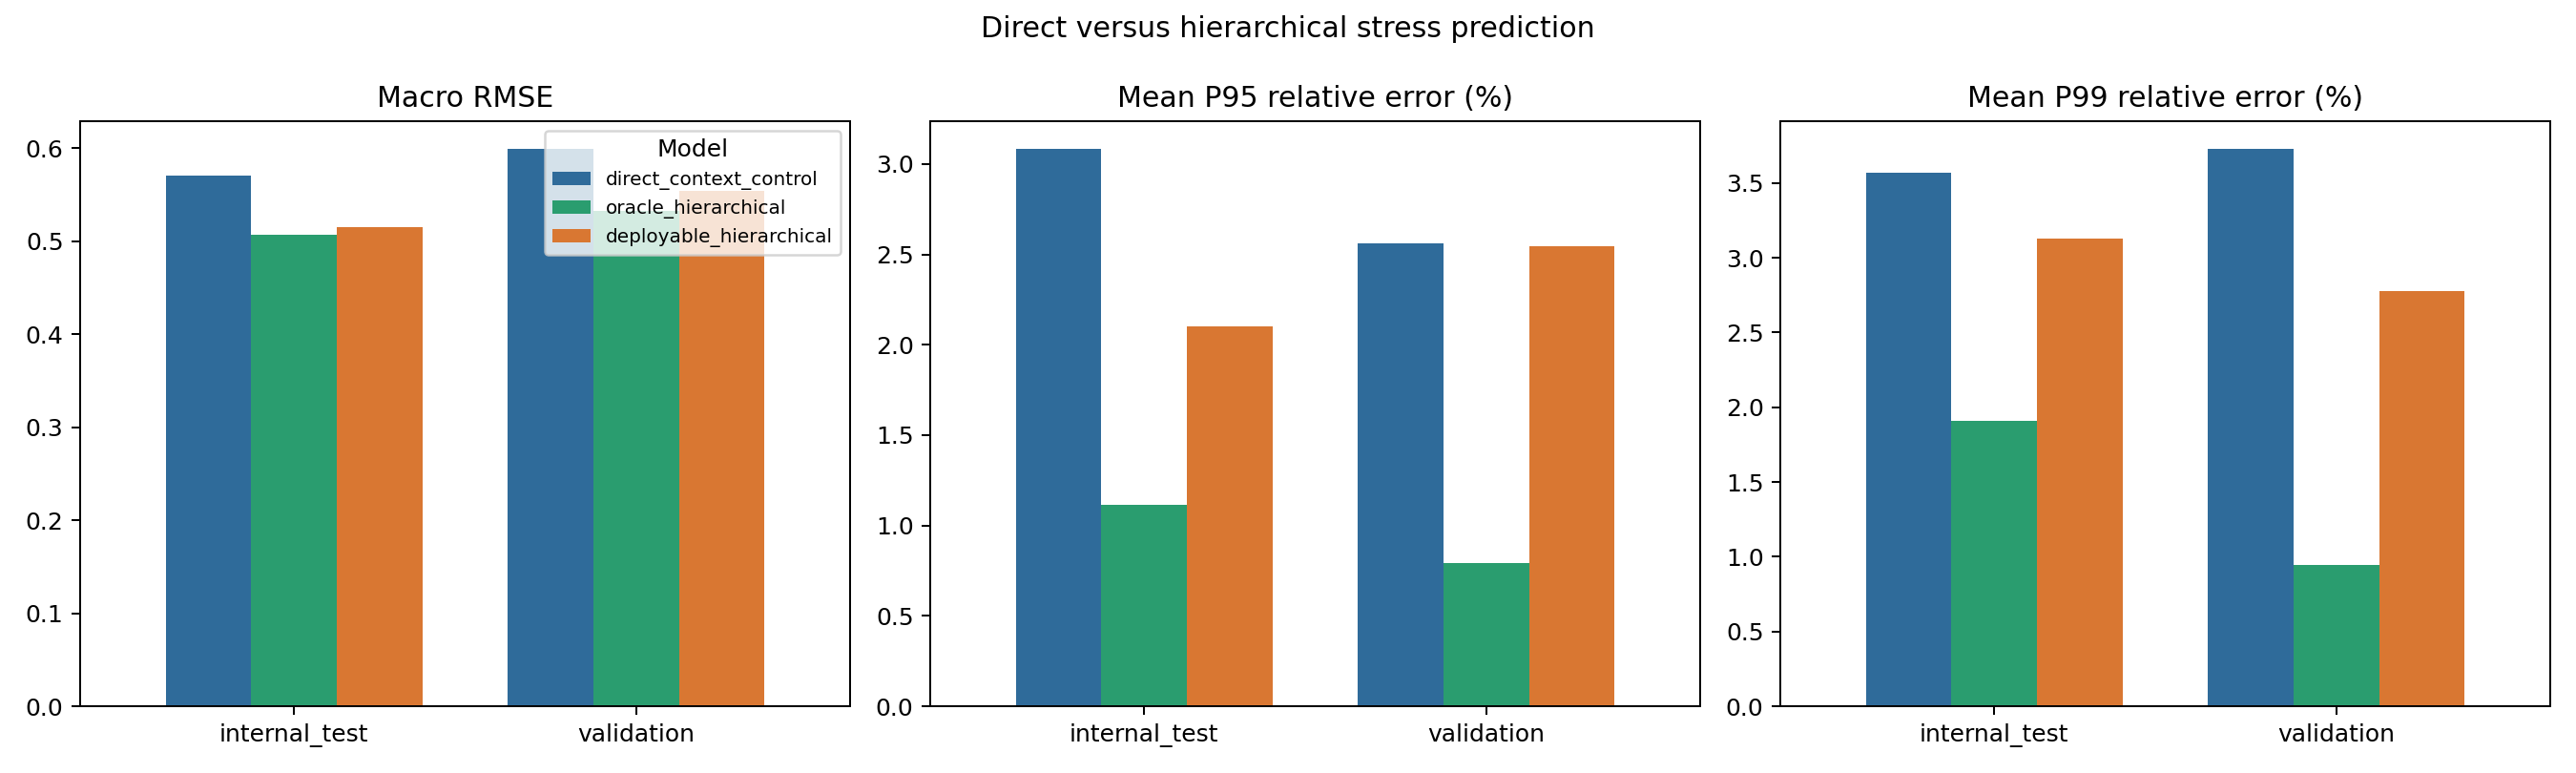

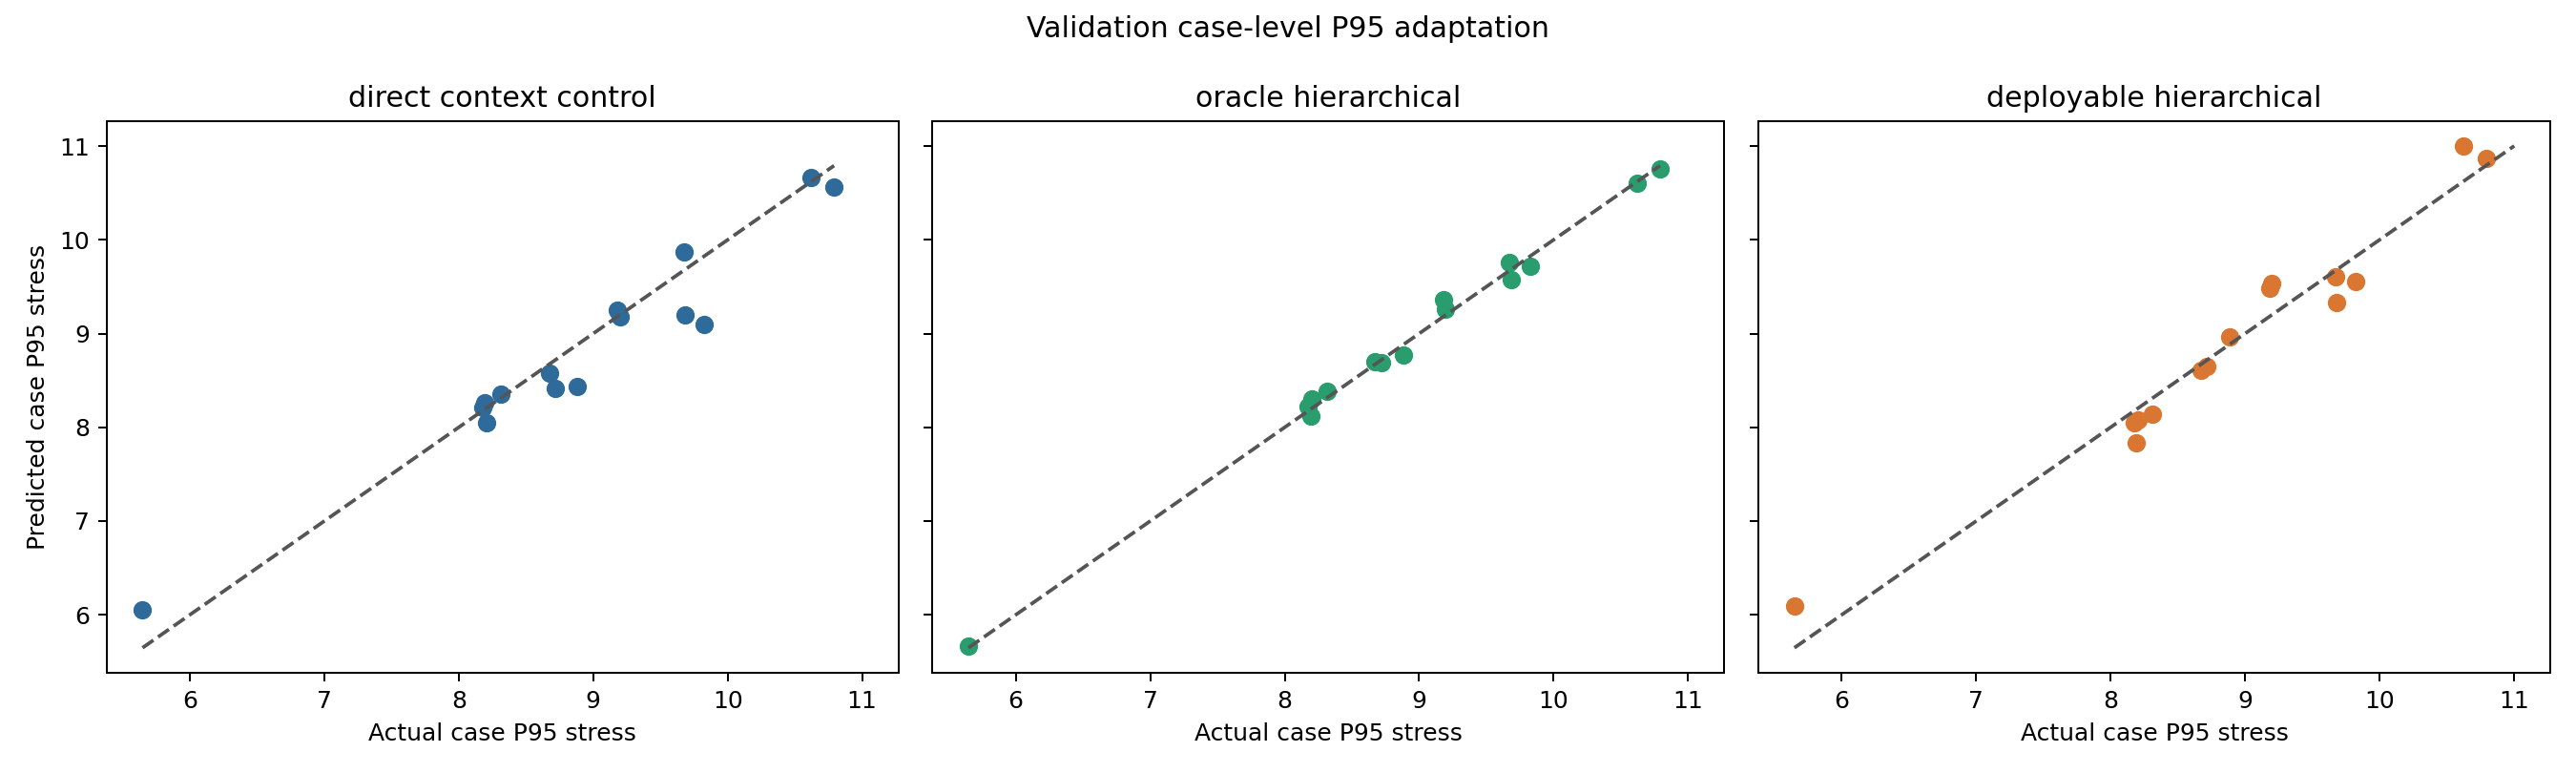

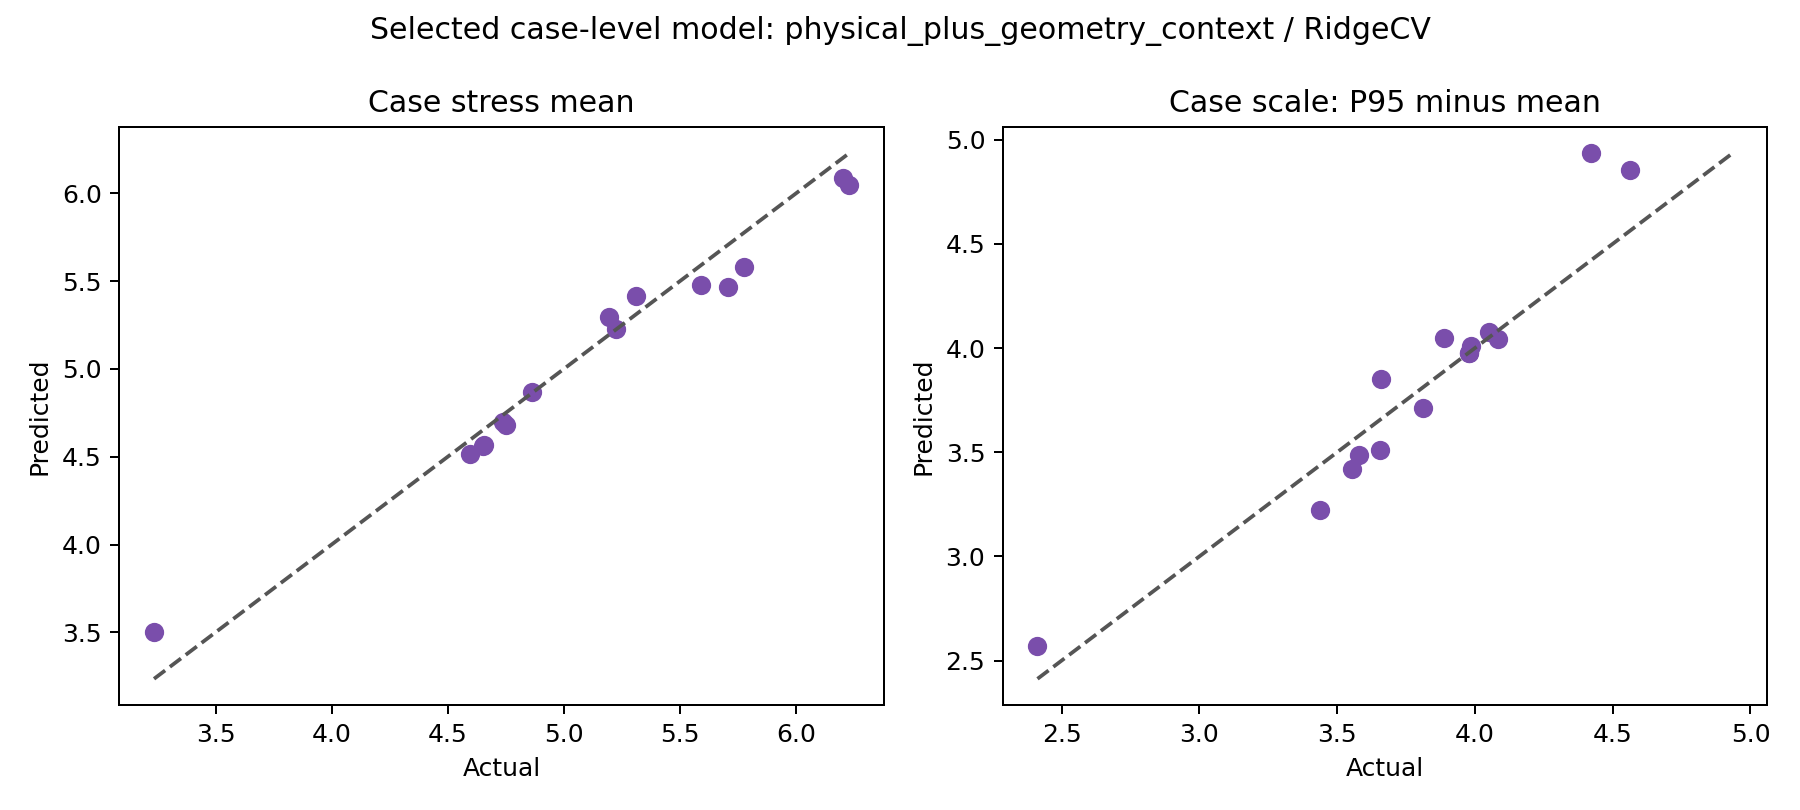

In [4]:
from IPython.display import Image, display as show

OUTPUT_DIR = Path(RESULTS["run_summary"]["output_directory"])
for figure_name in [
    "hierarchical_method_comparison.png",
    "validation_p95_adaptation.png",
    "case_amplitude_prediction.png",
]:
    show(Image(filename=str(OUTPUT_DIR / figure_name)))


## Takeaways and Decision Rule

Interpret the three methods separately:

- If the **oracle hierarchy** is clearly better than the direct control,
  normalised shape is learnable and decomposition is structurally useful.
- If oracle is good but the **deployable hierarchy** is poor, the main
  bottleneck is predicting case amplitude/offset from input summaries.
- If both hierarchical methods are comparable to or better than direct on
  validation and internal test, a two-stage symbolic-regression V5 is
  justified.
- If oracle is materially worse than direct, do not spend another long
  PySR run on this hierarchy. Revisit spatial representation or the target
  definition first.

The automated 5% comparison flags are screening aids, not proof. The
final decision must also inspect P95/P99 error, underprediction, hotspot
overlap, case ordering and consistency between validation and internal
test. The final 50 cases remain sealed regardless of this result.
